In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import os
import scipy
import matplotlib.cm as cm
from datetime import datetime
import seaborn as sns
import pytz
import matplotlib
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn import metrics
from sklearn.metrics import r2_score

Before loading in the conductivity data, ensure you have calculated the proper datetime based off of the time the C3PO was plugged into power, which was recorded in Notes.txt. Ensure to save these datetimes as a column. It is easy to do in excel, and you can use previous calibration csvs for an example. 

You'll also need to create a "step_pts_interp.csv" file in the working folder that "fills in" points from every step change from the step_pts.txt file for every 20 seconds. Again, use previous spreadsheets as an example if needed. 

Check your conductivity data beforehand and remove points that were taken while moving the probe from one solution to the other if needed (often appears as 0 or an erroneous value when you know the sensor was coming in or out of the solution at that time). 

In [57]:
# USER INPUT 
filename = 'conductivity' #data from the calibration 
device = 'C3PO_6' 
folder = '2026_07_22_Calibration'

filepath = os.path.join(device, folder, filename+'.csv') 
cond = pd.read_csv(filepath, header = 0, parse_dates =[7], date_format='%yyyy-%m-%d %HH:%MM:%SS') 
cond.head()
#cond.tail()

,Real_Time,Temp_C,Cond_uScm-1,CellVoltage,StateofCharge,ErrorCode,Elapsed_sec,datetime
0,946684805,22.27,0,0.84,99.24,0,0,2026-07-22 13:35:10
1,946684823,22.40,0,0.05,97.82,0,18,2026-07-22 13:35:28
2,946684843,22.40,0,0.05,96.39,0,38,2026-07-22 13:35:48
3,946684862,22.40,0,0.05,94.81,0,57,2026-07-22 13:36:07
4,946684882,22.40,0,0.05,93.23,0,77,2026-07-22 13:36:27


In [58]:
filename = 'step_pts' #data from the calibration 
filepath = os.path.join(device, folder, filename+'.txt') 
steps = pd.read_csv(filepath, header = 0, parse_dates =['datetime'], date_format='%yyyy-%m-%d %HH:%MM:%SS') 
steps.tail()

,cond_uscm,datetime
1,0,2026-7-22 13:49:00
2,12880,2026-7-22 13:50:25
3,12880,2026-7-22 13:58:00
4,80000,2026-7-22 13:59:28
5,80000,2026-7-22 14:05:00


In [59]:
cond['datetime'] = pd.to_datetime(cond['datetime'])
steps['datetime']= pd.to_datetime(steps['datetime'])


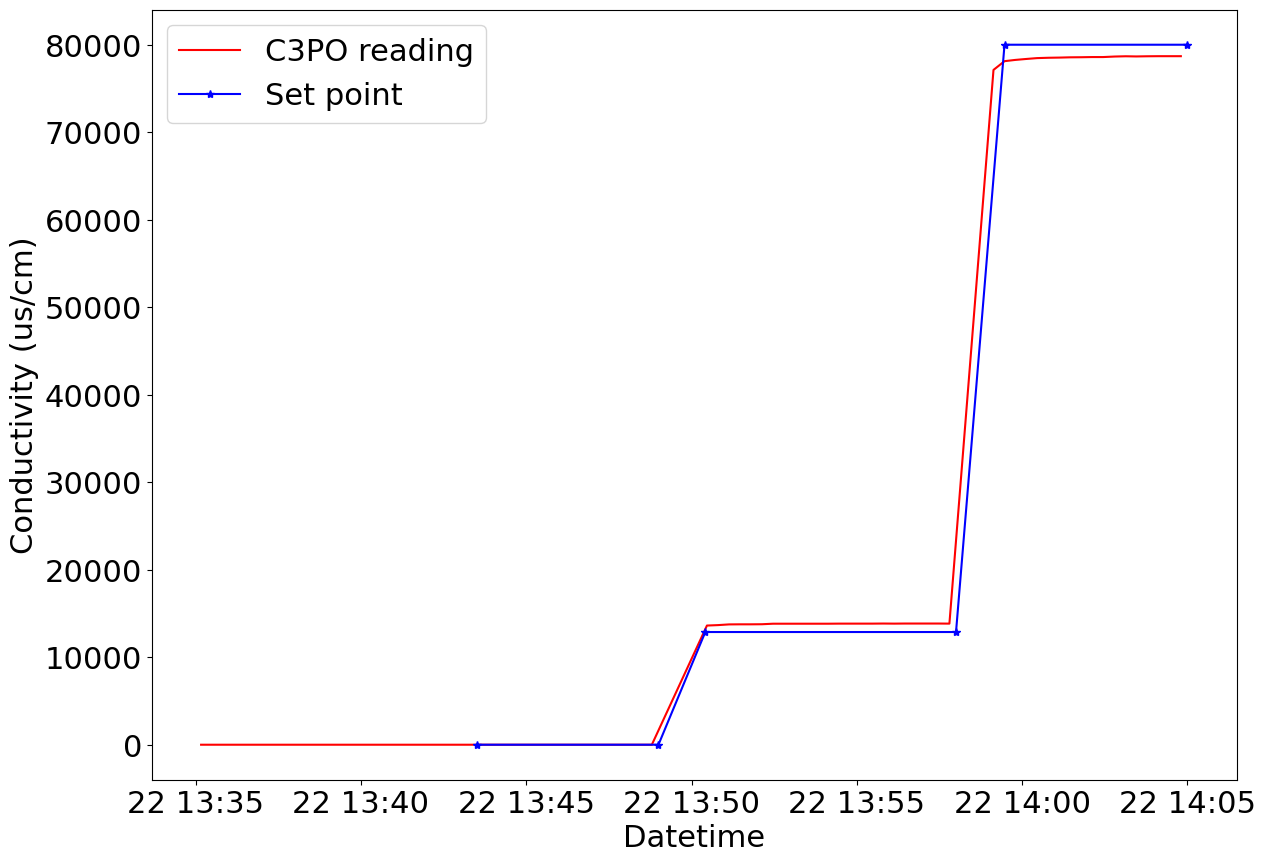

In [60]:
#Plot raw points 
plt.rcParams.update({'font.size': 22})
fig, axs = plt.subplots(figsize = (14, 10))

axs.plot(cond["datetime"], cond["Cond_uScm-1"], label = "C3PO reading", color = "red")
axs.plot(steps["datetime"], steps["cond_uscm"], label = "Set point", marker = '*', color = "blue")
axs.set_ylabel('Conductivity (us/cm)')
axs.set_xlabel('Datetime')

plt.legend()

fig_fn = 'RawReadings'
fig_file = os.path.join(device, folder, 'Figures', device+fig_fn+'.png')
plt.savefig(fig_file, dpi = 200, transparent=False)

In [61]:
filename = 'step_pts_interp' 
filepath = os.path.join(device, folder, filename+'.csv') 
steps2 = pd.read_csv(filepath, header = 0, parse_dates =['datetime'], date_format='%yyyy-%m-%d %HH:%MM:%SS') 
steps2['datetime']= pd.to_datetime(steps2['datetime'])
steps2.head()

,cond_uscm,datetime
0,0,2026-07-22 13:43:30
1,0,2026-07-22 13:43:50
2,0,2026-07-22 13:44:10
3,0,2026-07-22 13:44:30
4,0,2026-07-22 13:44:50


In [62]:
merged = pd.merge_asof(steps2, cond, on='datetime', direction='nearest')
filepath = os.path.join(device, folder, 'merged.csv') 
merged.to_csv(filepath, index=False)
print(merged)

    cond_uscm            datetime  Real_Time  Temp_C  Cond_uScm-1  \
0           0 2026-07-22 13:43:30  946685302   22.65            0   
1           0 2026-07-22 13:43:50  946685323   23.06            0   
2           0 2026-07-22 13:44:10  946685343   23.08            0   
3           0 2026-07-22 13:44:30  946685363   23.10            0   
4           0 2026-07-22 13:44:50  946685382   23.13            0   
5           0 2026-07-22 13:45:10  946685402   23.15            0   
6           0 2026-07-22 13:45:30  946685423   23.17            0   
7           0 2026-07-22 13:45:50  946685443   23.18            0   
8           0 2026-07-22 13:46:10  946685463   23.19            0   
9           0 2026-07-22 13:46:30  946685482   23.20            0   
10          0 2026-07-22 13:46:50  946685502   23.21            0   
11          0 2026-07-22 13:47:10  946685523   23.21            0   
12          0 2026-07-22 13:47:30  946685543   23.21            0   
13          0 2026-07-22 13:47:50 

In [63]:
filename = 'merged' 
filepath = os.path.join(device, folder, filename+'.csv') 
mergedcleaned = pd.read_csv(filepath, header = 0, parse_dates =['datetime'], date_format='%yyyy-%m-%d %HH:%MM:%SS') 
mergedcleaned['datetime']= pd.to_datetime(mergedcleaned['datetime'])
mergedcleaned.head()

,cond_uscm,datetime,Real_Time,Temp_C,Cond_uScm-1,CellVoltage,StateofCharge,ErrorCode,Elapsed_sec
0,0,2026-07-22 13:43:30,946685302,22.65,0,0.05,62.53,0,497
1,0,2026-07-22 13:43:50,946685323,23.06,0,0.05,61.06,0,518
2,0,2026-07-22 13:44:10,946685343,23.08,0,0.05,59.79,0,538
3,0,2026-07-22 13:44:30,946685363,23.10,0,0.05,58.53,0,558
4,0,2026-07-22 13:44:50,946685382,23.13,0,0.05,56.95,0,577


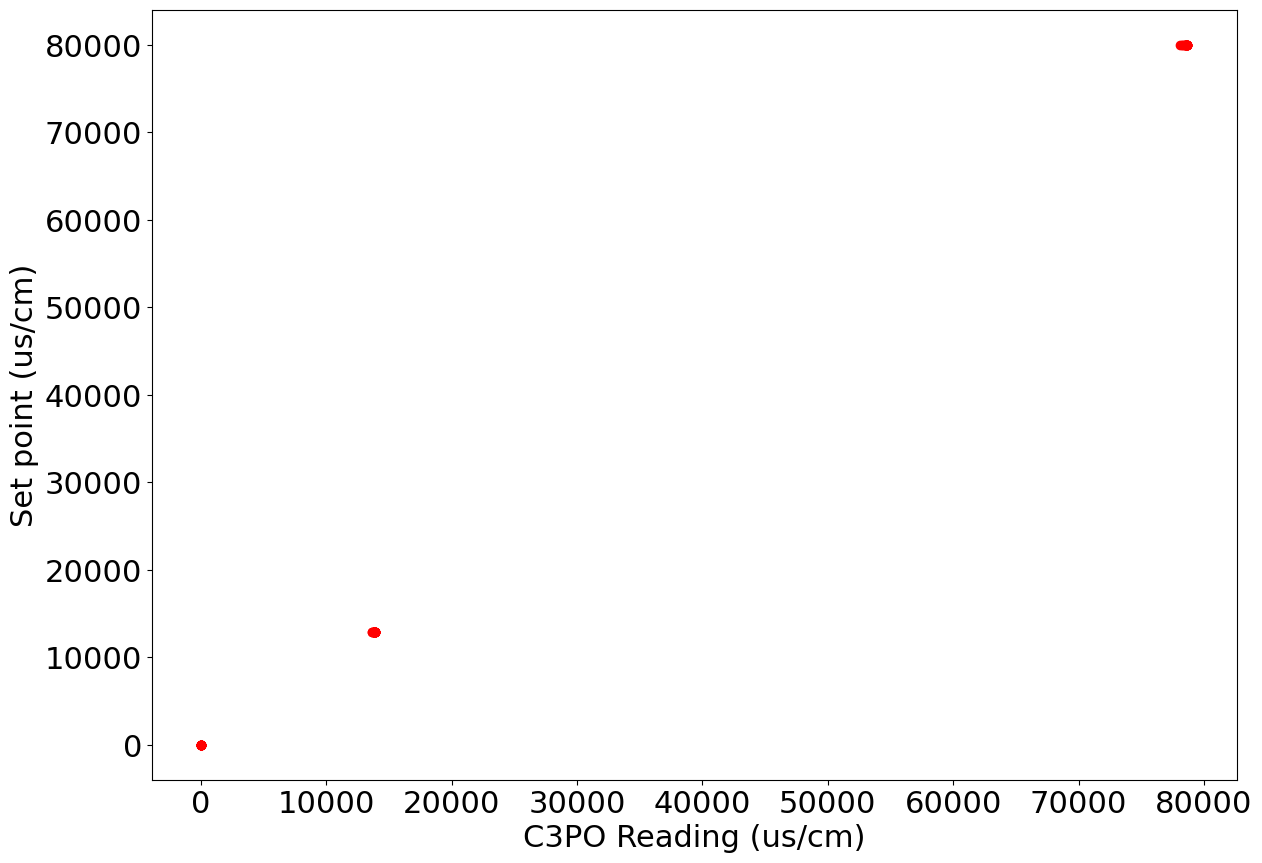

In [64]:
plt.rcParams.update({'font.size': 22})
fig, axs = plt.subplots(figsize = (14, 10))

axs.scatter(mergedcleaned["Cond_uScm-1"], mergedcleaned["cond_uscm"], color = "red")
axs.set_ylabel('Set point (us/cm)')
axs.set_xlabel('C3PO Reading (us/cm)')

fig_fn = 'versusSetPoint'
fig_file = os.path.join(device, folder, 'Figures', device+fig_fn+'.png')
plt.savefig(fig_file, dpi = 200, transparent=False)

In [65]:
y = mergedcleaned["cond_uscm"]
x = mergedcleaned["Cond_uScm-1"] 

coef = np.polyfit(x,y,1)
print(coef)
poly1d_fn = np.poly1d(coef) 
y_predicted = poly1d_fn(x)
r_squared = r2_score(y, y_predicted)
print(f"R² Value: {r_squared:.4f}")

[   1.02507152 -668.01395061]
R² Value: 0.9997


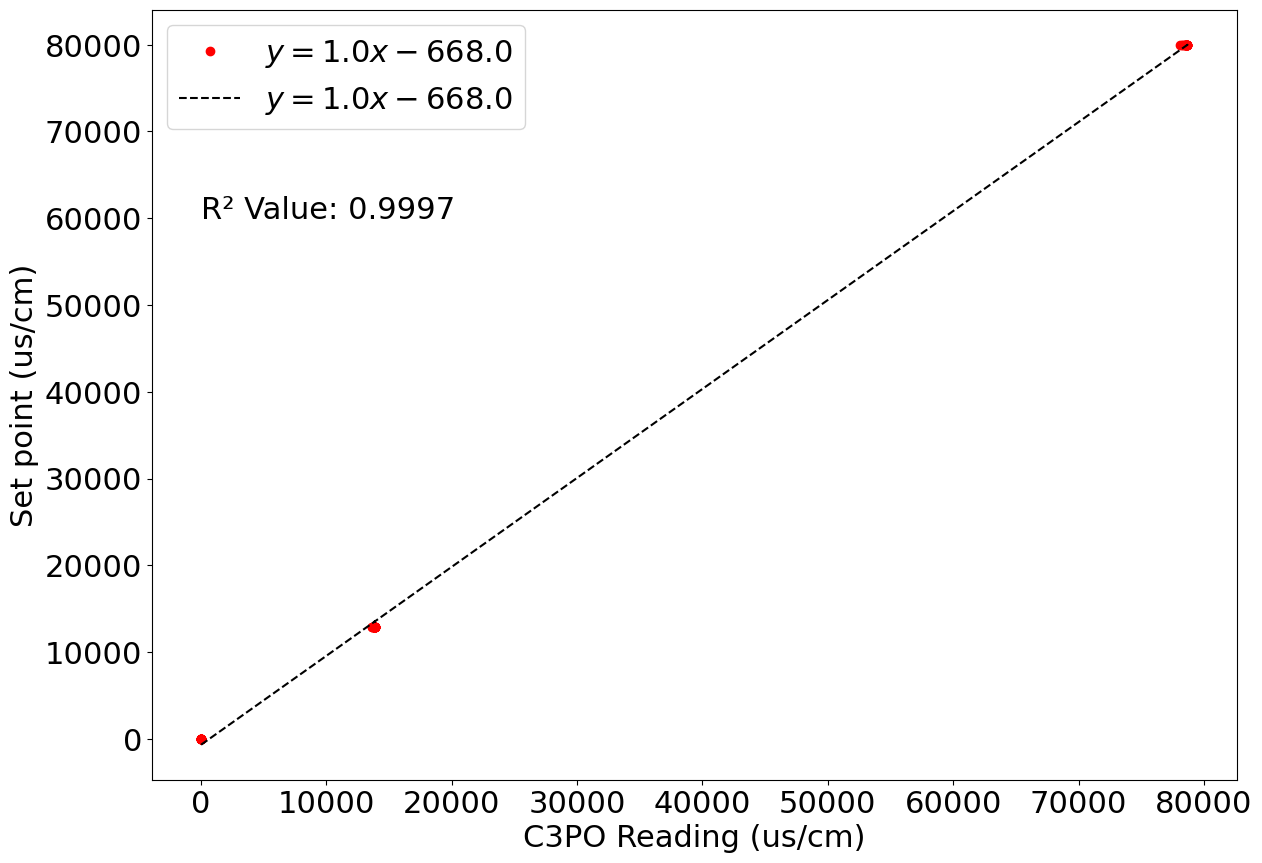

In [66]:
plt.rcParams.update({'font.size': 22})
fig, axs = plt.subplots(figsize = (14, 10))

m = coef[0]
b = coef[1]

axs.set_ylabel('Set point (us/cm)')
axs.set_xlabel('C3PO Reading (us/cm)')
axs.plot(x,y, 'ro', x, poly1d_fn(x), '--k', label=f'$y = {m:.1f}x {b:+.1f}$') 

plt.legend()
plt.text(0, 60000, f"R² Value: {r_squared:.4f}")


fig_fn = 'vsSetPoint_withRegression'
fig_file = os.path.join(device, folder, 'Figures', device+fig_fn+'.png')
plt.savefig(fig_file, dpi = 200, transparent=False)

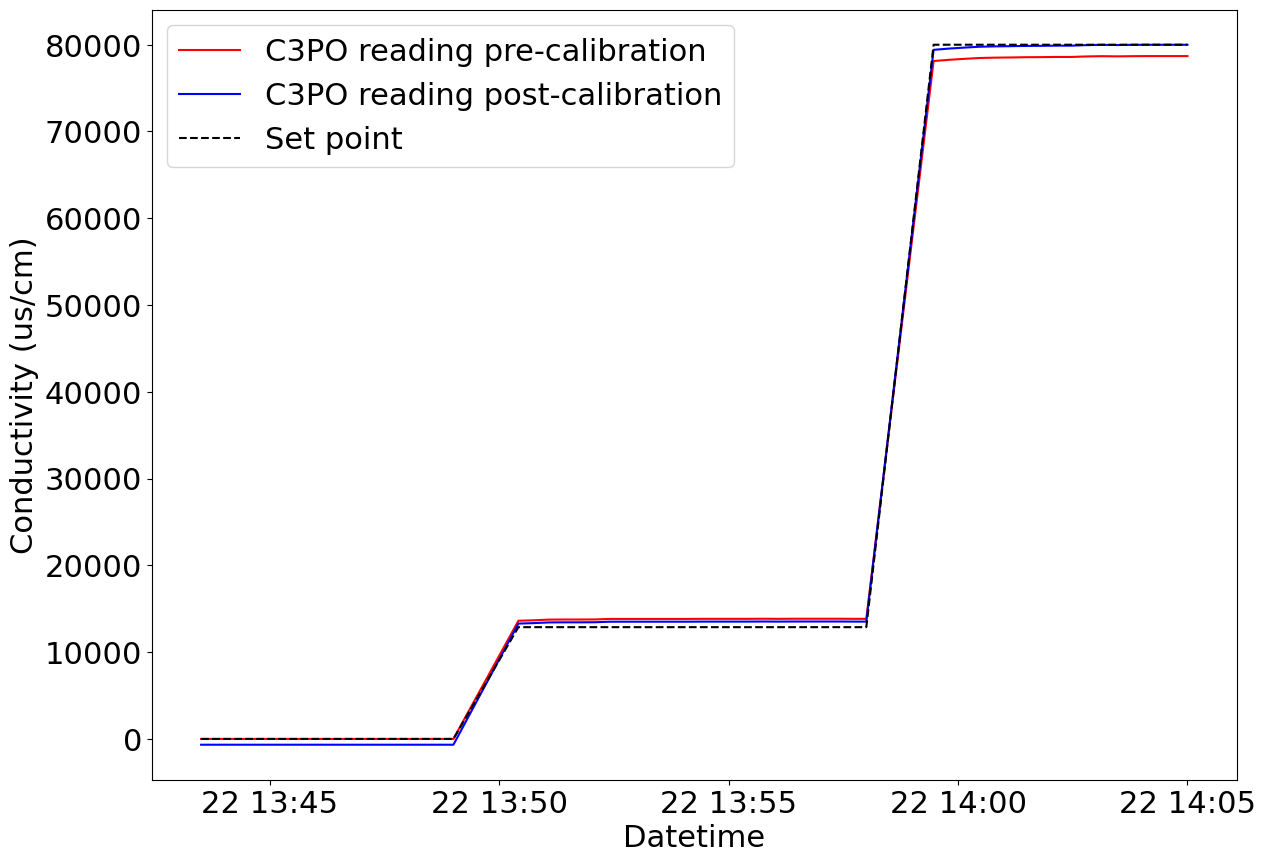

In [67]:
plt.rcParams.update({'font.size': 22})
fig, axs = plt.subplots(figsize = (14, 10))

axs.plot(mergedcleaned["datetime"], mergedcleaned["Cond_uScm-1"], label = "C3PO reading pre-calibration", color = "red")
axs.plot(mergedcleaned["datetime"], m*mergedcleaned["Cond_uScm-1"] + b, label = "C3PO reading post-calibration", color = "blue")
axs.plot(mergedcleaned["datetime"], mergedcleaned["cond_uscm"] , label = "Set point", linestyle = '--', color = 'black')
axs.set_ylabel('Conductivity (us/cm)')
axs.set_xlabel('Datetime')

plt.legend()

fig_fn = 'PreandPostCalibration'
fig_file = os.path.join(device, folder, 'Figures', device+fig_fn+'.png')
plt.savefig(fig_file, dpi = 200, transparent=False)